1. Problem Statement
   
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.


2. Objective

1 Clean and prepare the data for analysis.
2 Examine how agricultural performance varies across seasons.
3 Identify important seasonal patterns and trends.
4 Investigate relationships between seasonal conditions and agricultural outcomes.
5 Compare relevant groups within different seasons.
6 Identify significant differences or unusual patterns.
7 Apply appropriate statistical and visualization techniques.
8 Interpret findings based on evidence from the dataset.
9 Develop meaningful conclusions and data-driven recommendations. 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

3. Initial Data Understanding

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [14]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [15]:
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,...,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,...,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,...,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,...,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,...,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [17]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [7]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [10]:
df['Season'].unique()

<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

In [11]:
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [14]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [16]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [17]:
df.groupby('Season')['Yield_Tonnes_Ha'].mean()

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64

In [18]:
df.groupby('Season')['Production_Tonnes'].mean()

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

In [19]:
df.groupby('Season')['Profit_INR'].mean()

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

In [20]:
seasonal_analysis = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']
].mean()

seasonal_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Season,,,
Kharif,5.643973,46.311192,178914.647555
Rabi,5.080498,41.486712,87689.470191
Zaid,4.665942,38.886111,-24804.824916


5. Statistical Analysis

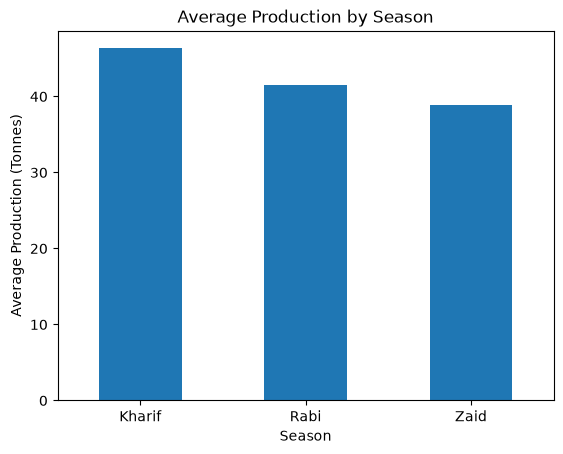

In [22]:
seasonal_analysis['Production_Tonnes'].plot(kind='bar')

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=0)
plt.show()


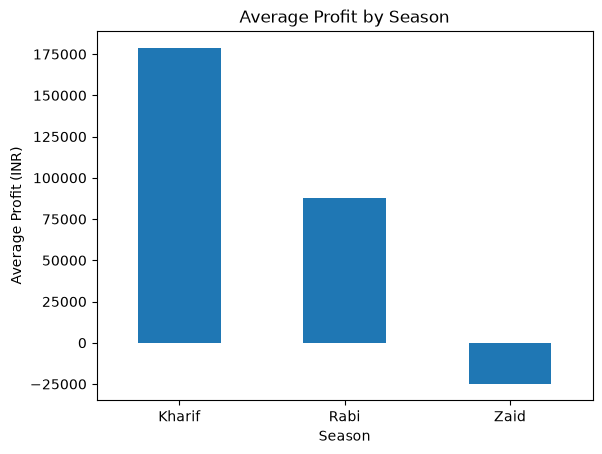

In [23]:
seasonal_analysis['Profit_INR'].plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)
plt.show()

In [24]:
df.groupby('Season')[
    ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
].mean()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct
Season,,,
Kharif,852.084205,28.454019,71.812591
Rabi,436.000124,23.489183,57.893178
Zaid,299.421784,31.042088,52.012121


In [25]:
df.groupby('Season')[
    ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
].mean()

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.201237,5.891834
Rabi,5846.987093,5.186122
Zaid,6419.893939,4.413239


In [26]:
seasonal_analysis = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']
].mean()

seasonal_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Season,,,
Kharif,5.643973,46.311192,178914.647555
Rabi,5.080498,41.486712,87689.470191
Zaid,4.665942,38.886111,-24804.824916


In [27]:
environmental_analysis = df.groupby('Season')[
    ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
].mean()

environmental_analysis

,Rainfall_mm,Avg_Temperature_C,Humidity_pct
Season,,,
Kharif,852.084205,28.454019,71.812591
Rabi,436.000124,23.489183,57.893178
Zaid,299.421784,31.042088,52.012121


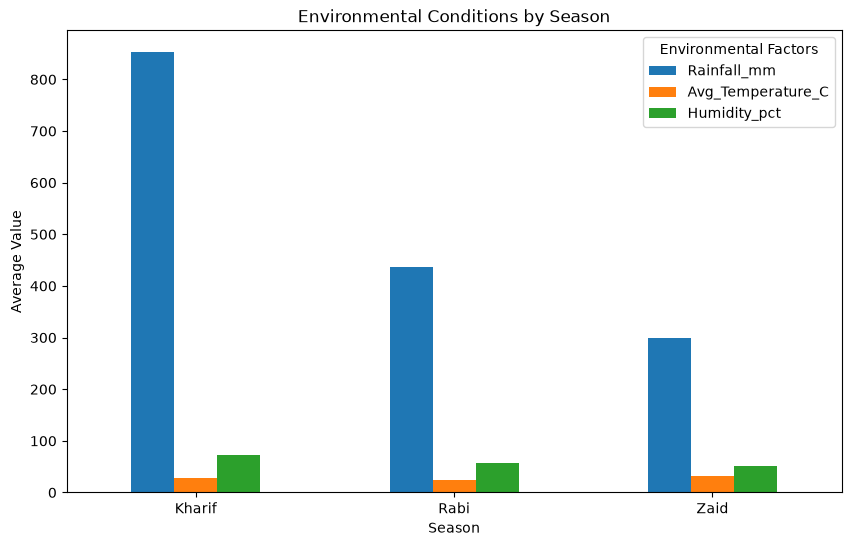

In [28]:
environmental_analysis.plot(kind='bar', figsize=(10,6))

plt.title('Environmental Conditions by Season')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Environmental Factors')
plt.show()

In [5]:
water_analysis = df.groupby('Season')[
    ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
].mean()

water_analysis

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.201237,5.891834
Rabi,5846.987093,5.186122
Zaid,6419.893939,4.413239


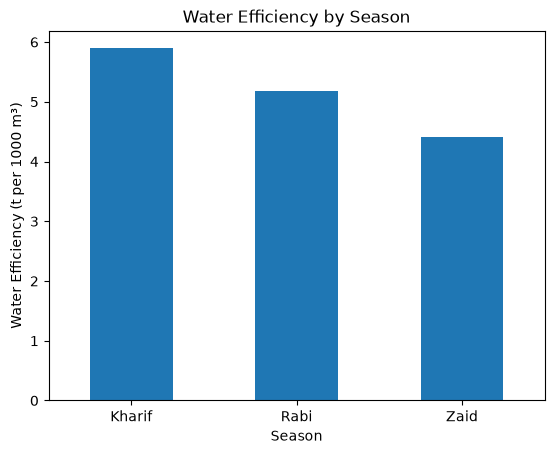

In [6]:
water_analysis['Water_Efficiency_t_per_1000m3'].plot(kind='bar')

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (t per 1000 m³)')
plt.xticks(rotation=0)
plt.show()

In [7]:
crop_season = df.groupby(['Season', 'Crop'])[
    'Yield_Tonnes_Ha'
].mean().unstack()

crop_season

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731413,1.372804,1.483646,2.966410,1.036063,2.707621,53.459120,2.255430
Rabi,1.461615,1.192915,1.221445,2.614913,0.871887,2.333680,43.940394,2.058814
Zaid,1.177742,0.951648,1.037778,2.297590,0.652131,1.900490,38.423922,1.748588


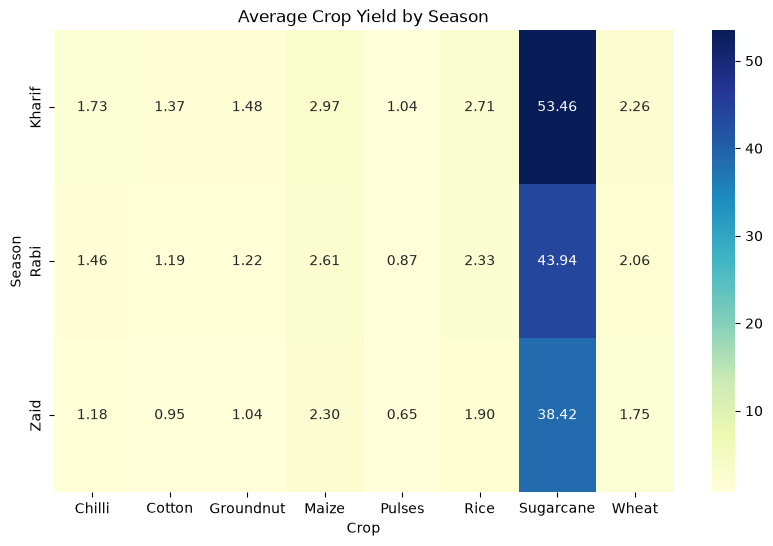

In [8]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Crop')
plt.ylabel('Season')
plt.show()

In [9]:
crop_season

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731413,1.372804,1.483646,2.966410,1.036063,2.707621,53.459120,2.255430
Rabi,1.461615,1.192915,1.221445,2.614913,0.871887,2.333680,43.940394,2.058814
Zaid,1.177742,0.951648,1.037778,2.297590,0.652131,1.900490,38.423922,1.748588


In [10]:
state_analysis = df.groupby('State')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']
].mean().sort_values('Profit_INR', ascending=False)

state_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
State,,,
Punjab,6.121116,52.233099,136025.636364
Maharashtra,5.030333,43.984043,135428.855469
Karnataka,5.734493,47.732720,119422.335378
Tamil Nadu,4.901247,40.840371,117744.748454
Gujarat,5.699586,48.331988,117568.235656
Telangana,5.076810,39.254186,108829.616279
Madhya Pradesh,5.029654,37.559517,86840.756539
Andhra Pradesh,4.650781,36.913157,73453.527410


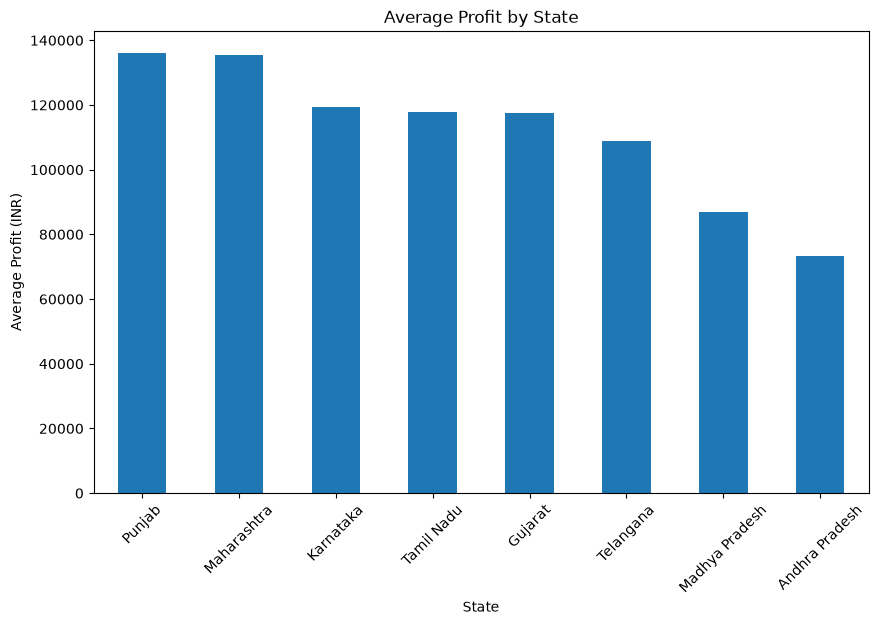

In [11]:
state_analysis['Profit_INR'].plot(kind='bar', figsize=(10,6))

plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

In [12]:
risk_analysis = df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean()

risk_analysis

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

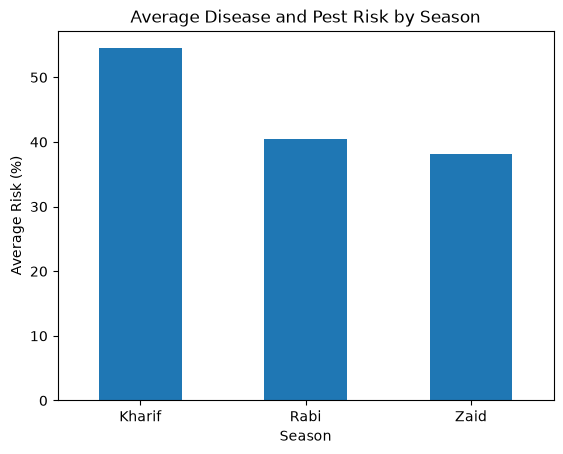

In [13]:
risk_analysis.plot(kind='bar')

plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Average Risk (%)')
plt.xticks(rotation=0)
plt.show()

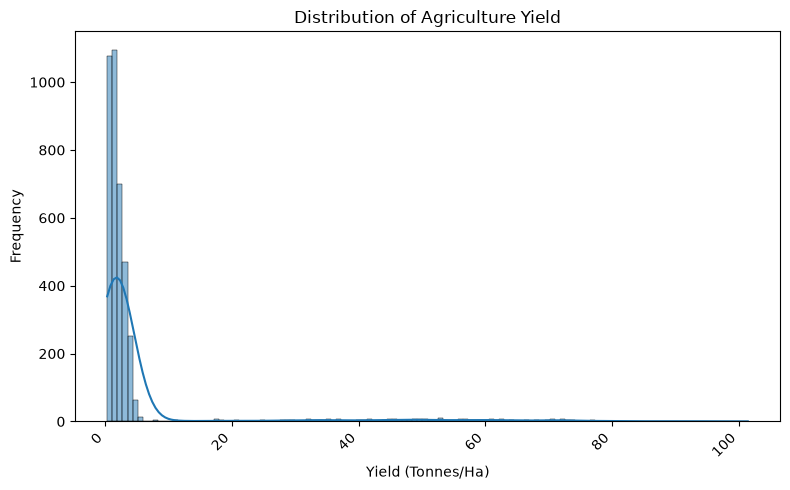

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Agriculture Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

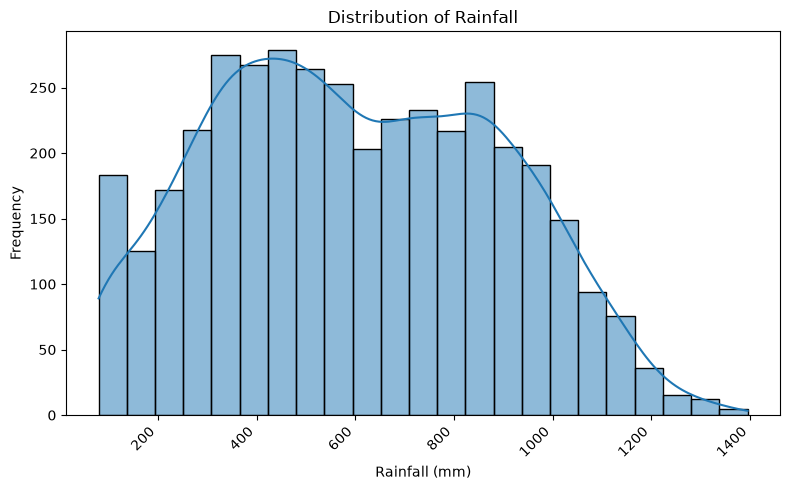

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Rainfall_mm", kde=True)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

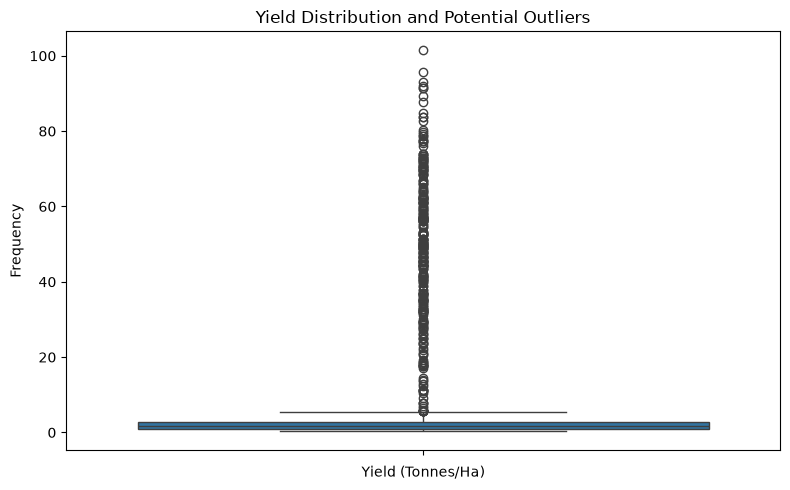

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

.Outlier

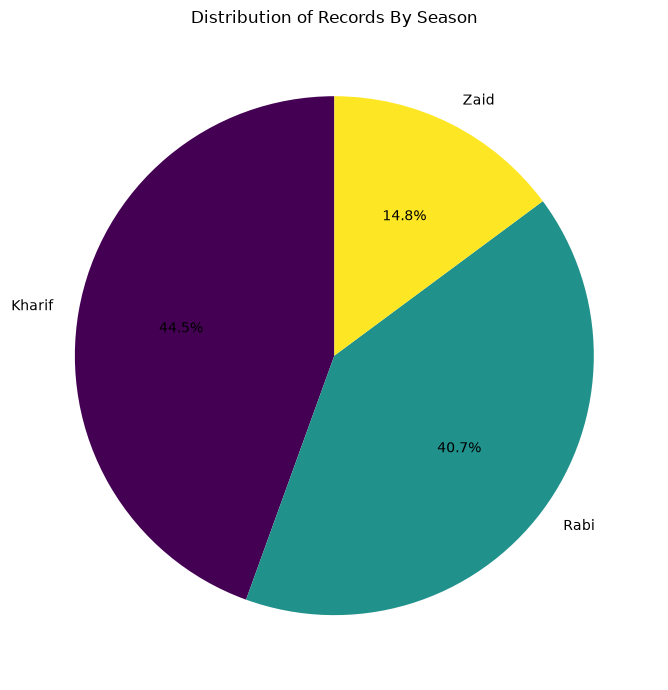

In [26]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title("Distribution of Records By Season")
plt.ylabel('')
plt.tight_layout()
plt.show()

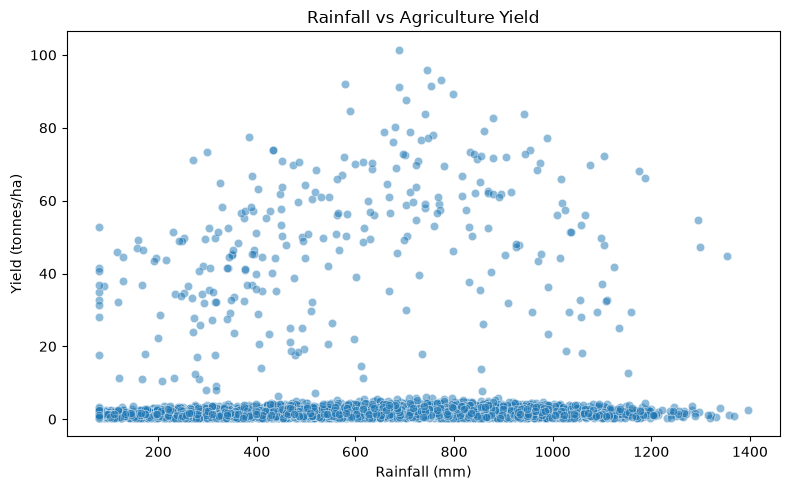

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    alpha=0.5
)

plt.title("Rainfall vs Agriculture Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

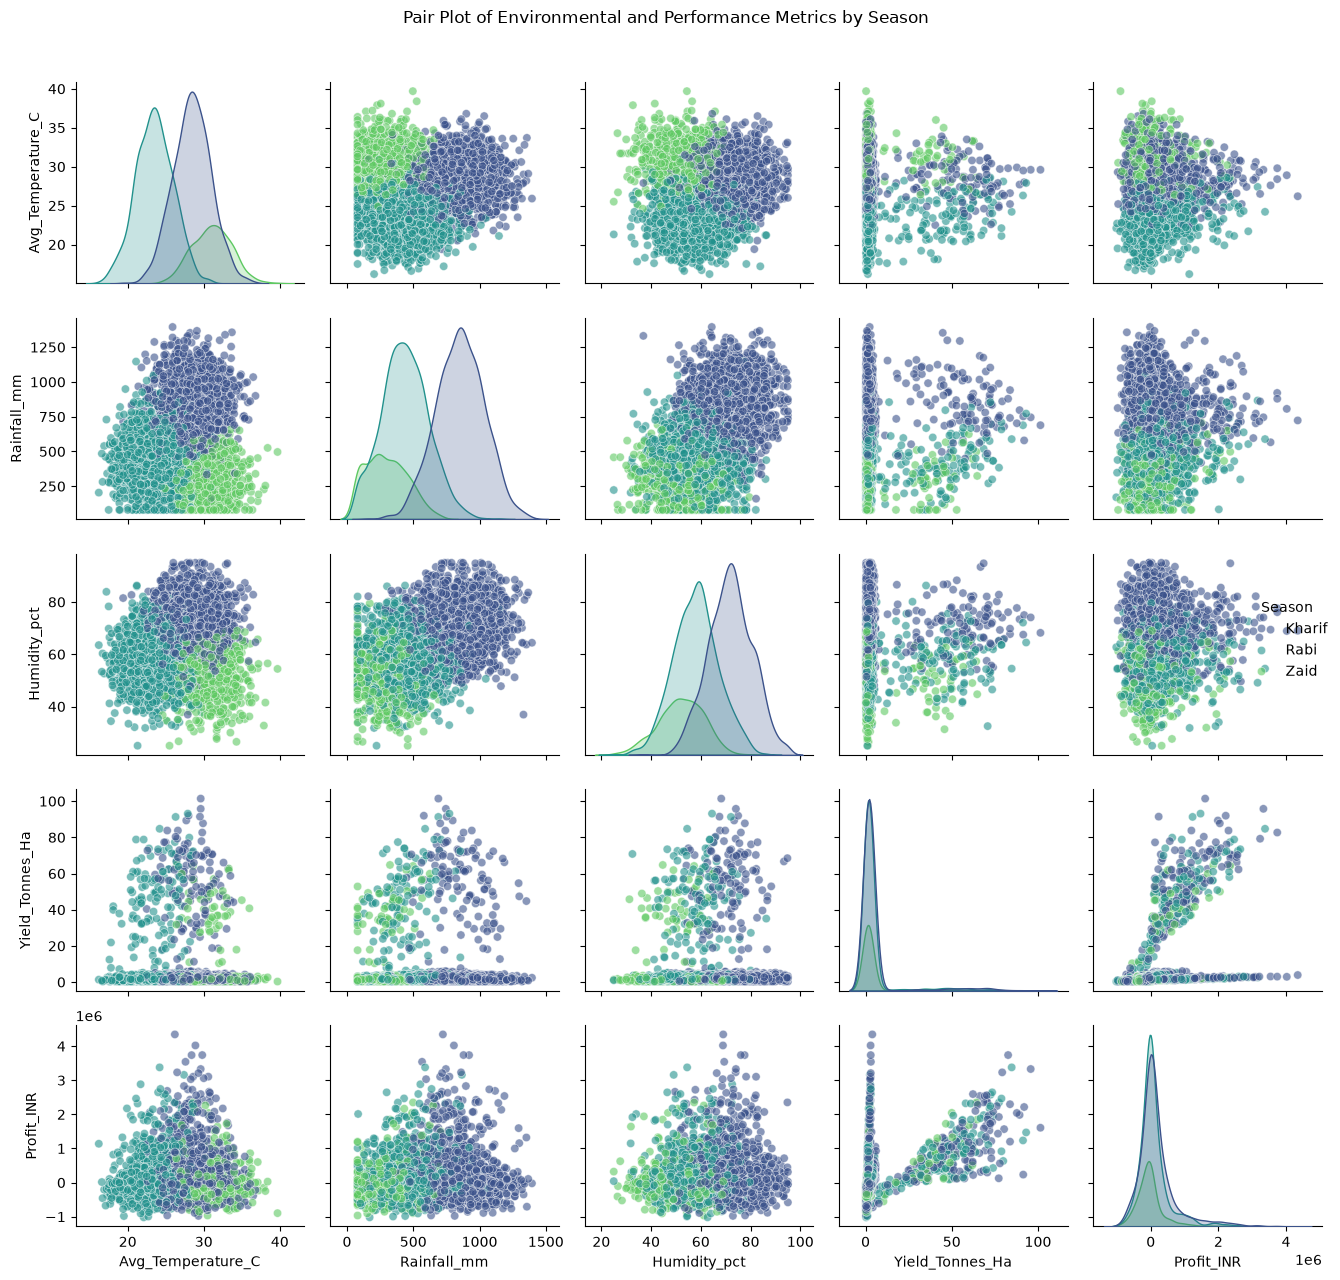

In [8]:
selected_columns = [
    'Avg_Temperature_C',
    'Rainfall_mm',
    'Humidity_pct',
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Season'
]

sns.pairplot(
    df[selected_columns],
    hue='Season',
    palette='viridis',
    plot_kws={'alpha': 0.6}
)

plt.suptitle(
    'Pair Plot of Environmental and Performance Metrics by Season',
    y=1.02
)

plt.tight_layout()
plt.show()

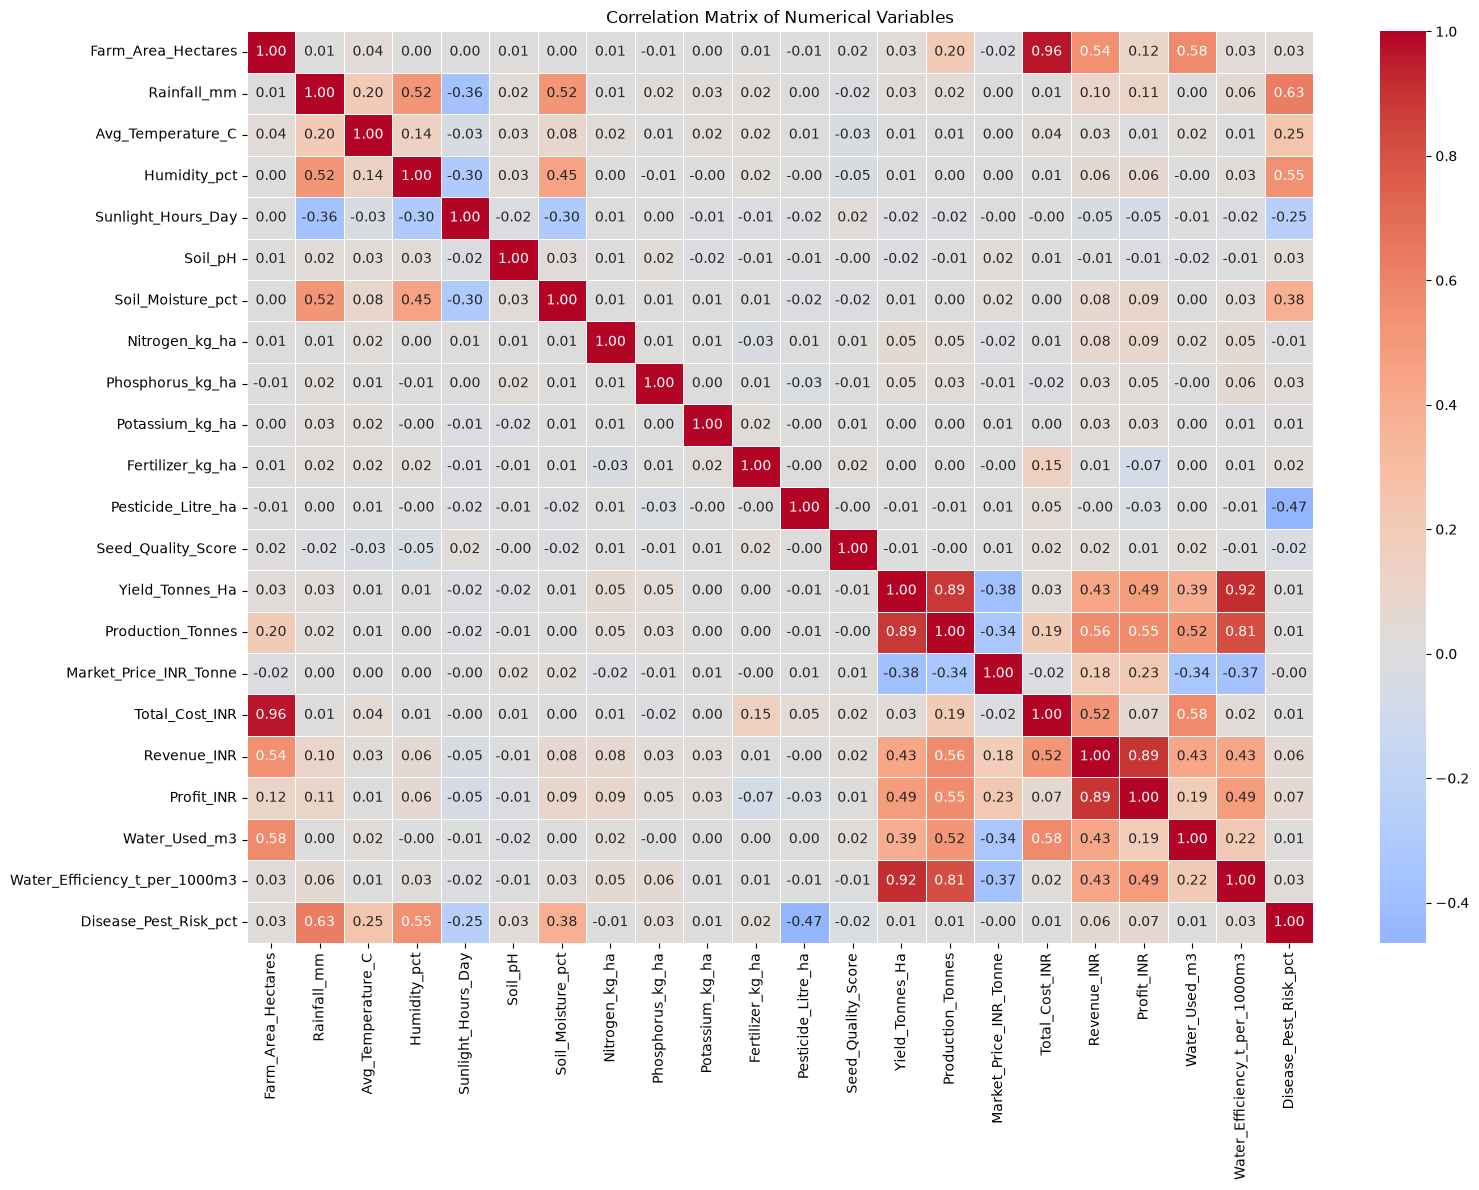

In [10]:
numeric_columns = df.select_dtypes(include='number').columns
corr = df[numeric_columns].corr()
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [11]:
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR","mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.64,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.08,67498.88,87689.47,142670768,5846.99
Zaid,594,4.67,23098.35,-24804.82,-14734066,6419.89


Conclusion


The agricultural seasonal performance analysis shows that crop production varies across different seasons due to factors such as rainfall, temperature, irrigation, soil conditions, and farming practices. By comparing production and cultivated area across seasons, we can identify high-performing and low-performing periods and understand seasonal trends. The analysis can help farmers and agricultural planners make better decisions about crop selection, resource allocation, irrigation, and productivity improvement. Overall, studying seasonal performance supports more efficient and sustainable agricultural planning.